Pandas version : 2.3.3
Seaborn version : 0.13.2
Matplotlib version : 3.10.7

DataFrame :
       Nom  Score
0    Alice     85
1      Bob     90
2  Charlie     78
3    David     92


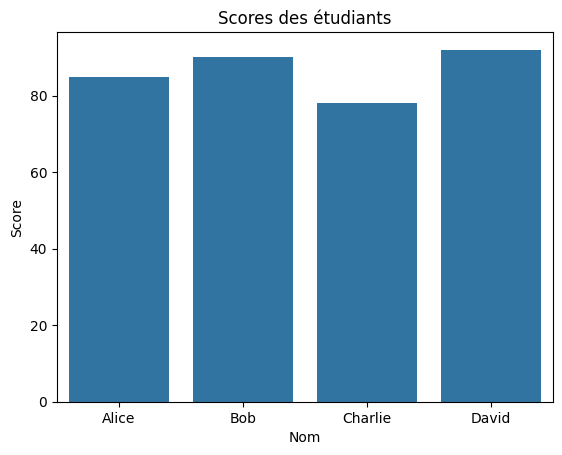

In [ ]:
# Importation des bibliothèques
import pandas as pd          # Pour la manipulation et l'analyse de données
import seaborn as sns        # Pour la visualisation statistique
import matplotlib.pyplot as plt  # Pour la personnalisation et le rendu des graphiques
import ast                     # Pour évaluer les chaînes de caractères contenant des structures de données (ex: listes, dictionnaires)

# Vérification des versions installées
print("Pandas version :", pd.__version__)
print("Seaborn version :", sns.__version__)
print("Matplotlib version :", plt.matplotlib.__version__)

# Exemple rapide : création d'un DataFrame et affichage d'un graphique
data = {
    "Nom": ["Alice", "Bob", "Charlie", "David"],
    "Score": [85, 90, 78, 92]
}

df = pd.DataFrame(data)

# Affichage du DataFrame
print("\nDataFrame :")
print(df)

# Visualisation simple avec Seaborn
sns.barplot(x="Nom", y="Score", data=df)
plt.title("Scores des étudiants")
plt.show()


In [ ]:
#Lecture du fichier CSV


# Lire le CSV
df = pd.read_csv(
    "tmdb_5000_movies.csv",
    sep=",",
    quotechar='"',
    encoding="utf-8"
)

# Colonnes à convertir
colonnes_json = ["genres", "keywords", "production_companies", "production_countries", "spoken_languages"]

# Transformer le texte en vraies listes Python
for col in colonnes_json:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])

# Exemple : afficher juste les noms des genres du premier film
premier_genres = [g["name"] for g in df.loc[0, "genres"]]
print("Genres du premier film :", premier_genres)

# Exemple : afficher les 5 premiers titres avec leurs genres
for i in range(5):
    titre = df.loc[i, "title"]
    genres = [g["name"] for g in df.loc[i, "genres"]]
    print(f"{titre} → {genres}")




Genres du premier film : ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
Avatar → ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
Pirates of the Caribbean: At World's End → ['Adventure', 'Fantasy', 'Action']
Spectre → ['Action', 'Adventure', 'Crime']
The Dark Knight Rises → ['Action', 'Crime', 'Drama', 'Thriller']
John Carter → ['Action', 'Adventure', 'Science Fiction']


In [21]:
# Dimensions du dataset
print(df.shape)

# Aperçu des premières lignes
df.head()

# Vérifier les valeurs manquantes
df.isnull().sum()

# Statistiques de base
df.describe()

# Supprimer les lignes où la durée est 0
df = df[df["runtime"] > 0]

# Supprimer les lignes où la note est 0
df = df[df["vote_average"] > 0]

# Supprimer les lignes où le nombre de votes est trop faible (peu fiable)
df = df[df["vote_count"] >= 10]

# Vérification du résultat
print(df.shape)

(4386, 21)
(4386, 21)


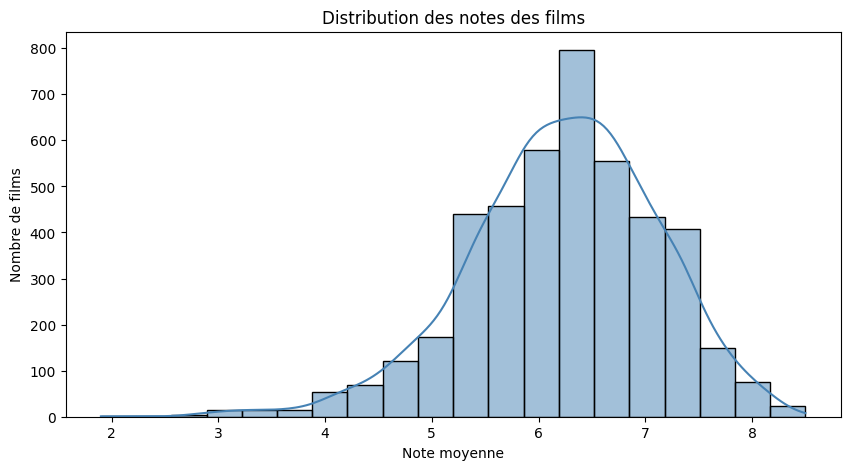

In [22]:
# Distribution des notes
plt.figure(figsize=(10, 5))
sns.histplot(df["vote_average"], bins=20, kde=True, color="steelblue")
plt.title("Distribution des notes des films")
plt.xlabel("Note moyenne")
plt.ylabel("Nombre de films")

plt.savefig("distribution_notes.png", bbox_inches="tight")
plt.show()

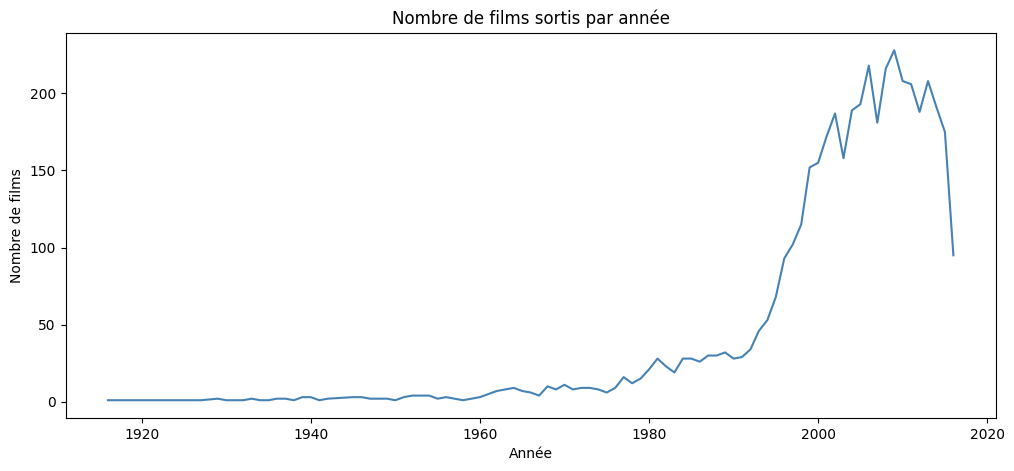

In [19]:
# Extraire l'année depuis la colonne release_date
df["release_year"] = pd.to_datetime(df["release_date"], errors="coerce").dt.year

# Compter le nombre de films par année
films_par_an = df["release_year"].value_counts().sort_index()

# Visualisation
plt.figure(figsize=(12, 5))
sns.lineplot(x=films_par_an.index, y=films_par_an.values, color="steelblue")
plt.title("Nombre de films sortis par année")
plt.xlabel("Année")
plt.ylabel("Nombre de films")

plt.savefig("Nombre_de_films.png", bbox_inches="tight")
plt.show()

C:\Users\hadiz\AppData\Local\Temp\ipykernel_29148\1978713858.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="vote_average", y="title", data=top10, palette="Blues_d")


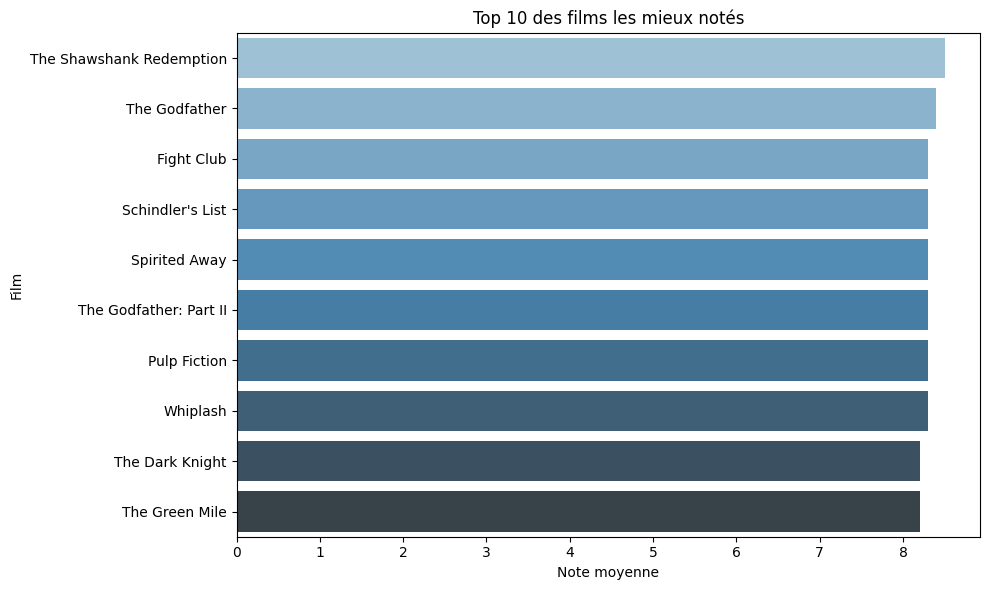

In [20]:
# Filtrer les films avec suffisamment de votes pour être fiables
top10 = df[df["vote_count"] >= 100].nlargest(10, "vote_average")[["title", "vote_average"]]

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x="vote_average", y="title", data=top10, palette="Blues_d")
plt.title("Top 10 des films les mieux notés")
plt.xlabel("Note moyenne")
plt.ylabel("Film")
plt.tight_layout()

plt.savefig("top10_films.png", bbox_inches="tight")
plt.show()